In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

In [2]:
# -------------------------------------------------------------------
# 0.  Imports
# -------------------------------------------------------------------
import scanpy as sc
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error,r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# XGBoost is optional – comment out if not available
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except ImportError:
    HAVE_XGB = False
    print("XGBoost not found – skipping that model")


In [3]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 


import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
all_spatial= adata_mer.obsm['spatial']
all_spatial = processing.get_hemi(all_spatial, mesh_LC)    
all_spatial*= 25

In [4]:
# load nicheformer results 
fileloc = '/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/adata_mer_embedded_2025-05-27.h5ad'
adata_niche = sc.read_h5ad(fileloc)

In [5]:
adata_niche.X.max()

np.float64(839.0)

In [5]:

# -------------------------------------------------------------------
# 1.  Extract design matrix (genes) and targets (XYZ)
# -------------------------------------------------------------------
# adata_mer: AnnData with (n_cells=2600, n_genes=314)

# 1a.  Gene expression matrix (dense is fine for 2 600 × 314)
X = adata_niche.obsm['nicheformer']

coords = all_spatial.copy()

In [6]:

# -------------------------------------------------------------------
# 2.  Data split: 60 / 20 / 20
# -------------------------------------------------------------------
# 1) first split: train vs tmp (val+test)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X,coords, 
    test_size=0.40,
    random_state=42
)

# 2) second split: val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,y_tmp,
    test_size=0.50,
    random_state=42
)

In [7]:

# -------------------------------------------------------------------
# 3.  Helper for training & evaluation
# -------------------------------------------------------------------
def fit_and_report(name, model, param_grid=None, scale=True):
    """
    Train |model| (optionally grid-searching over param_grid) and
    print/return MSE for val+test.
    """
    steps = []
    if scale:          # scaling is rarely useful for tree-based models
        steps.append(("scaler", StandardScaler()))
    steps.append(("reg", model))
    pipe = Pipeline(steps)

    if param_grid is None:
        pipe.fit(X_train, y_train)
    else:
        cv = KFold(n_splits=5, shuffle=True, random_state=1)
        gs = GridSearchCV(
            pipe, param_grid, cv=cv, scoring="neg_mean_squared_error",
            n_jobs=-1, verbose=0
        )
        gs.fit(X_train, y_train)
        pipe = gs.best_estimator_
        print(f"[{name}] best params:", gs.best_params_)

    # validation performance
    y_val_pred = pipe.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred, multioutput="raw_values")
    print(f"[{name}] val MSE (x, y, z): {val_mse.round(4)}  |  mean={val_mse.mean():.4f}")

    # final retrain on train+val before testing
    pipe.fit(np.vstack([X_train, X_val]), np.vstack([y_train, y_val]))
    y_test_pred = pipe.predict(X_test)
    
    test_mse = mean_squared_error(y_test, y_test_pred, multioutput="raw_values")
    test_r2  = r2_score(y_test, y_test_pred, multioutput="raw_values")
    print(f"[{name}] TEST MSE (x,y,z): {test_mse.round(2)};  mean={test_mse.mean():.2f}")
    print(f"[{name}] TEST  R² (x,y,z): {test_r2.round(3)};  mean={test_r2.mean():.3f}\n")

    return name, pipe, test_mse, test_r2



In [8]:
# -------------------------------------------------------------------
# 4.  Model zoo
# -------------------------------------------------------------------
results = []

# 4.1  Linear regression (baseline)
results.append(fit_and_report("Linear", LinearRegression(), scale=True))

# 4.2  Ridge (tune α)
ridge_grid = {"reg__alpha": np.logspace(-3, 3, 7)}
results.append(
    fit_and_report("Ridge", Ridge(), param_grid=ridge_grid, scale=True)
)

# 4.3  Random Forest
rf_grid = {
    "reg__n_estimators": [200, 500],
    "reg__max_depth": [None, 10, 30],
    "reg__min_samples_leaf": [1, 3, 10],
}
results.append(
    fit_and_report("RandomForest", RandomForestRegressor(random_state=0), rf_grid, scale=False)
)


[Linear] val MSE (x, y, z): [ 38175.4845 250427.1982  62266.5717]  |  mean=116956.4181
[Linear] TEST MSE (x,y,z): [ 35634.86 246505.2   51196.54];  mean=111112.20
[Linear] TEST  R² (x,y,z): [0.077 0.514 0.277];  mean=0.289



/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.11257e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.31968e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.26587e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned m

[Ridge] best params: {'reg__alpha': np.float64(100.0)}
[Ridge] val MSE (x, y, z): [ 30541.9382 218438.0183  50152.2241]  |  mean=99710.7269
[Ridge] TEST MSE (x,y,z): [ 30777.03 223558.15  43838.15];  mean=99391.11
[Ridge] TEST  R² (x,y,z): [0.203 0.559 0.381];  mean=0.381

[RandomForest] best params: {'reg__max_depth': 30, 'reg__min_samples_leaf': 3, 'reg__n_estimators': 500}
[RandomForest] val MSE (x, y, z): [ 34835.5943 311341.7726  57978.1786]  |  mean=134718.5152
[RandomForest] TEST MSE (x,y,z): [ 33628.14 341971.87  55329.97];  mean=143643.33
[RandomForest] TEST  R² (x,y,z): [0.129 0.325 0.219];  mean=0.224



In [9]:
# 4.4  Gradient Boosting (sklearn)
gb_base = MultiOutputRegressor(
    GradientBoostingRegressor(random_state=0)
)

gb_grid = {
    # Note the extra 'estimator' hop inside the pipeline:
    "reg__estimator__n_estimators": [300, 600],
    "reg__estimator__learning_rate": [0.05, 0.1],
    "reg__estimator__max_depth": [2, 3],
}

results.append(
    fit_and_report("GradBoost", gb_base, gb_grid, scale=False)
)



[GradBoost] best params: {'reg__estimator__learning_rate': 0.1, 'reg__estimator__max_depth': 3, 'reg__estimator__n_estimators': 600}
[GradBoost] val MSE (x, y, z): [ 34437.209  303600.972   62609.2655]  |  mean=133549.1488
[GradBoost] TEST MSE (x,y,z): [ 33365.44 281712.92  50142.98];  mean=121740.45
[GradBoost] TEST  R² (x,y,z): [0.136 0.444 0.292];  mean=0.291



In [10]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

# 4.5  XGBoost (optional)
if HAVE_XGB:
    xgb_base = MultiOutputRegressor(
        XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            random_state=0,
        )
    )

    # Now drill into the "estimator" inside the MultiOutputRegressor
    xgb_grid = {
        "reg__estimator__n_estimators": [400, 800],
        "reg__estimator__learning_rate": [0.05, 0.1],
        "reg__estimator__max_depth": [3, 5],
        "reg__estimator__subsample": [0.8, 1.0],
    }

    results.append(
        fit_and_report("XGBoost", xgb_base, xgb_grid, scale=False)
    )


[XGBoost] best params: {'reg__estimator__learning_rate': 0.05, 'reg__estimator__max_depth': 3, 'reg__estimator__n_estimators': 800, 'reg__estimator__subsample': 0.8}
[XGBoost] val MSE (x, y, z): [ 33384.4746 284609.6982  57155.2552]  |  mean=125049.8093
[XGBoost] TEST MSE (x,y,z): [ 32127.45 261137.31  47801.35];  mean=113688.70
[XGBoost] TEST  R² (x,y,z): [0.168 0.485 0.325];  mean=0.326



In [11]:
results[0][3]

array([0.0770882 , 0.51366779, 0.27712505])

In [12]:

# -------------------------------------------------------------------
# 5.  Leaderboard
# -------------------------------------------------------------------
print("\n=== Test-set leaderboard (mean MSE) ===")
for name, _, mse, r2 in sorted(results, key=lambda t: t[2].mean()):
    print(f"{name:<12}  r2={r2.mean():2f} mean MSE: {mse.mean():.2f}  (x={mse[0]:.2f}, y={mse[1]:.2f}, z={mse[2]:.2f})")



=== Test-set leaderboard (mean MSE) ===
Ridge         r2=0.380955 mean MSE: 99391.11  (x=30777.03, y=223558.15, z=43838.15)
Linear        r2=0.289294 mean MSE: 111112.20  (x=35634.86, y=246505.20, z=51196.54)
XGBoost       r2=0.325930 mean MSE: 113688.70  (x=32127.45, y=261137.31, z=47801.35)
GradBoost     r2=0.290690 mean MSE: 121740.45  (x=33365.44, y=281712.92, z=50142.98)
RandomForest  r2=0.224381 mean MSE: 143643.33  (x=33628.14, y=341971.87, z=55329.97)


In [13]:
best_name, best_model, best_mse, best_r2 = min(results, key=lambda t: t[2].mean())
print(f"🏆  Best model = {best_name}, mean R2 ={best_r2.mean():2f} mean MSE = {best_mse.mean():.2f}")

🏆  Best model = Ridge, mean R2 =0.380955 mean MSE = 99391.11


# visualize the predicted results

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3-D projection
import numpy as np

def plot_xyz_predictions(model, X, y_true, n_show=None, title="XYZ prediction"):
    """
    3-D scatter of ground-truth coordinates and model predictions.
    Optionally draws error vectors (ŷ − y) for a small random subset.
    """
    y_pred = model.predict(X)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    
    # true locations
    ax.scatter(*y_true.T, c="k", s=8, alpha=0.5, label="true")
    # predictions
    ax.scatter(*y_pred.T, c="tab:orange", s=8, alpha=0.5, label="pred")
    
    # draw arrows for a subset so the plot stays readable
    if n_show is None:
        n_show = min(75, len(y_true))
    idx = np.random.choice(len(y_true), n_show, replace=False)
    for i in idx:
        ax.plot(
            [y_true[i, 0], y_pred[i, 0]],
            [y_true[i, 1], y_pred[i, 1]],
            [y_true[i, 2], y_pred[i, 2]],
            lw=0.6, c="gray", alpha=0.4
        )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()
    ax.set_title(title + f"\nmean MSE = {((y_true - y_pred)**2).mean():.4f}")
    plt.tight_layout()
    plt.show()


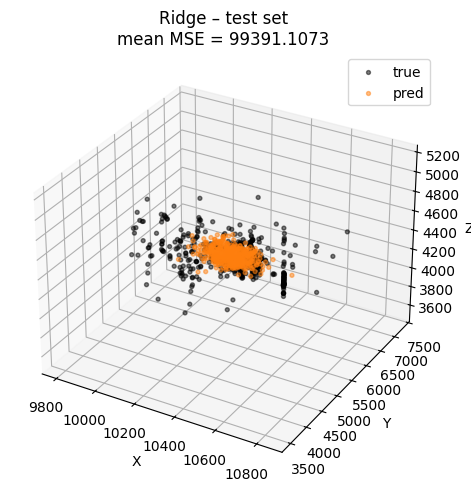

In [15]:
plot_xyz_predictions(best_model, X_test, y_test, n_show=10,
                     title=f"{best_name} – test set")


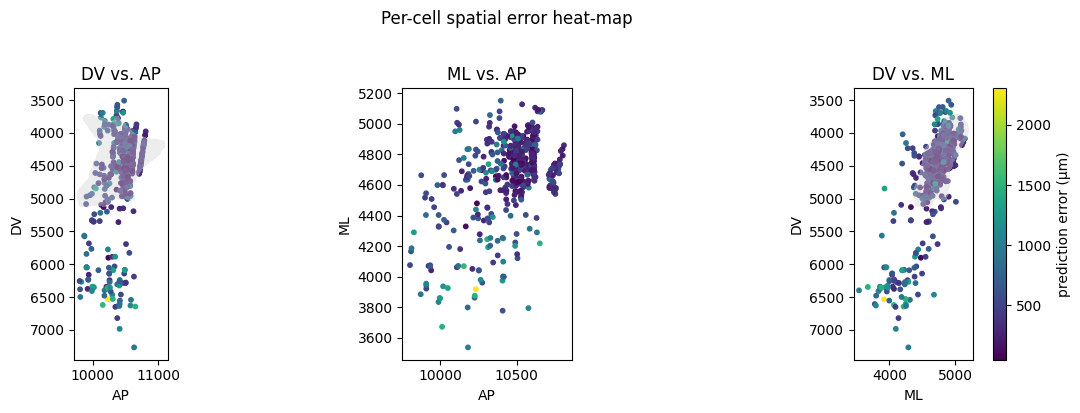

In [16]:
almeshes = utils.load_mesh()

def plot_2d_projections(model, X, y_true):
    y_pred = model.predict(X)
    diffs   = np.sqrt(((y_true - y_pred)**2).sum(1))   # Euclidean error per cell
    cmap    = plt.cm.viridis
    panels = [("AP","DV",(0,1)), ("AP","ML",(0,2)), ("ML","DV",(2,1))]

    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    for ax, (labx, laby, (i,j)) in zip(axs, panels):
        sc = ax.scatter(y_true[:,i], y_true[:,j],
                        c=diffs, s=10, cmap=cmap, vmin=diffs.min(), vmax=diffs.max())
        ax.set_xlabel(labx); ax.set_ylabel(laby)
        ax.set_aspect("equal")
        ax.set_title(f"{laby} vs. {labx}")
    plotting.plot_mesh(ax=axs[0], allmeshes=almeshes, direction='s')
    plotting.plot_mesh(ax=axs[2], allmeshes=almeshes, direction='c')
    fig.colorbar(sc, ax=ax, label="prediction error (µm)")
    fig.suptitle("Per-cell spatial error heat-map", y=1.02)
    plt.tight_layout()

    
plot_2d_projections(best_model, X_test, y_test)


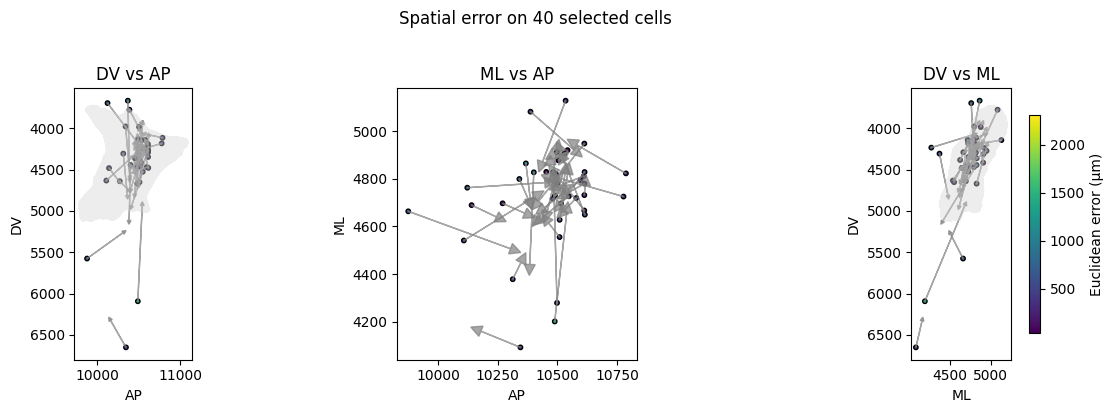

In [17]:


def plot_2d_projections_with_arrows(
    model, X, y_true, n_show=10, random_state=None, cmap=plt.cm.viridis
):
    """
    Plot 3 panels (XY, XZ, YZ) for a random subset of n_show cells,
    color‐coding by Euclidean error, and drawing arrows from true→predicted.
    """
    # predict
    y_pred = model.predict(X)
    # compute per‐cell Euclidean error
    errs = np.linalg.norm(y_true - y_pred, axis=1)
    
    # choose subset of indices
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(y_true), size=min(n_show, len(y_true)), replace=False)
    
    panels = [("AP","DV",(0,1)), ("AP","ML",(0,2)), ("ML","DV",(2,1))]
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    
    for ax, (labx, laby, (i,j)) in zip(axs, panels):
        # scatter only the chosen points
        sc = ax.scatter(
            y_true[idx, i], y_true[idx, j],
            c=errs[idx], s=10, cmap=cmap,
            vmin=errs.min(), vmax=errs.max(), edgecolor="k"
        )
        # draw arrows for each selected cell
        for k in idx:
            dx = y_pred[k, i] - y_true[k, i]
            dy = y_pred[k, j] - y_true[k, j]
            ax.arrow(
                y_true[k, i], y_true[k, j],
                dx, dy,
                head_width=0.02 * max(errs), head_length=0.02 * max(errs),
                fc="gray", ec="gray", alpha=0.7, length_includes_head=True
            )
        
        ax.set_xlabel(labx)
        ax.set_ylabel(laby)
        ax.set_aspect("equal")
        ax.set_title(f"{laby} vs {labx}")
    plotting.plot_mesh(ax=axs[0], allmeshes=almeshes, direction='s')
    plotting.plot_mesh(ax=axs[2], allmeshes=almeshes, direction='c')
    # shared colorbar
    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Euclidean error (µm)")
    fig.suptitle(f"Spatial error on {len(idx)} selected cells", y=1.02)
    plt.tight_layout()
    plt.show()


# Usage: select 10 random test cells and plot
plot_2d_projections_with_arrows(best_model, X_test, y_test, n_show=40, random_state=42)

In [18]:
X_test.shape

(531, 512)

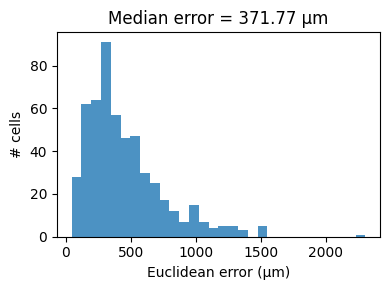

In [19]:
from scipy.spatial.distance import cdist

def plot_error_hist(model, X, y_true, bins=30):
    y_pred = model.predict(X)
    errs   = np.linalg.norm(y_true - y_pred, axis=1)   # Euclidean
    plt.figure(figsize=(4,3))
    plt.hist(errs, bins=bins, alpha=0.8)
    plt.xlabel("Euclidean error (µm)")
    plt.ylabel("# cells")
    plt.title(f"Median error = {np.median(errs):.2f} µm")
    plt.tight_layout()
    plt.show()
plot_error_hist(best_model, X_test, y_test)

# MAE

In [20]:
from sklearn.metrics import mean_absolute_error

y_pred = best_model.predict(X_test)

# y_true, y_pred are shape (n_samples, 3)
mae_per_axis = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
mae_mean     = mean_absolute_error(y_test, y_pred, multioutput="uniform_average")

print("MAE (AP, DV, ML):", mae_per_axis)
print("Average MAE:",    mae_mean)

MAE (AP, DV, ML): [135.8987746  365.48391878 156.40465727]
Average MAE: 219.2624502137027


In [21]:
np.ptp(y_test, 0)

array([1006.6404036 , 3758.69465508, 1612.98405375])

# pseudoclusters 

In [22]:
me = utils.load_mesh()
plt.scatter(df['ML'],df['DV'], c = df['pseudocluster'], cmap = 'PiYG', s=3)
plotting.plot_mesh(plt.gca(), allmeshes = me)

NameError: name 'df' is not defined

In [ ]:
plt.scatter(y_train[:,2],y_train[:,1], c = pc_train, cmap = 'PiYG');
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')

In [ ]:

model = LinearRegression().fit(pc_train.reshape(-1,1), y_train)
y_pred = model.predict(pc_test.reshape(-1,1))
print("MSE (mean):", mean_squared_error(y_test, y_pred, multioutput="uniform_average"))
print("R² (mean):", r2_score(y_test, y_pred, multioutput="uniform_average"))


model = Ridge().fit(pc_train.reshape(-1,1), y_train)
y_pred = model.predict(pc_test.reshape(-1,1))
print("MSE (mean):", mean_squared_error(y_test, y_pred, multioutput="uniform_average"))
print("R² (mean):", r2_score(y_test, y_pred, multioutput="uniform_average"))

# niceh results

In [ ]:
X_niche_train.shape, X_nishe_test.shape, X_niche_val.shape